In [2]:
import numpy as np
import matplotlib.pyplot as plt
from utils import *
from scipy.sparse import diags
from scipy.sparse.linalg import expm_multiply
plt.rcParams['figure.facecolor']='white'

In Shi Jin's formulation of the level set method, they have
$$
    \partial_t \phi + \nabla_p H \cdot \nabla_x \phi - \nabla_x H \cdot \nabla_p \phi = 0
$$
where $\phi(t,x,p)=0$ when $p=u(t,x)$.

Here we numerically simulate using the level set method.

We use $H(x,u)=x^2/2 + u^2/2$.
The initial condition for the first approach is $\phi(0,x,p) = p - u(0,x)$. We start with $u(0,x)$ being a Gaussian distribution.

This yields
$$
    \partial_t \phi + p \partial_x \phi - x \partial_p \phi = 0.
$$

In [70]:
N = 128+1
# m = 10
L = -1
R = 1

h = (R-L)/(N-1)
# omega = (m * h) ** (1/2)

T = 2.0
N_t = 64
times = np.linspace(0, T, N_t)

x, p = np.meshgrid(np.linspace(L, R, N), np.linspace(L, R, N), indexing='ij')
# X = np.stack([x0_tmp,x1_tmp], axis=-1)

In [71]:
mu = 0
sigma = 0.15

In [72]:
u_0 = np.exp(-0.5 * ((x - mu) / sigma) ** 2) / 1.2

In [73]:
psi_0 = p - u_0
psi_0 /= np.linalg.norm(psi_0)

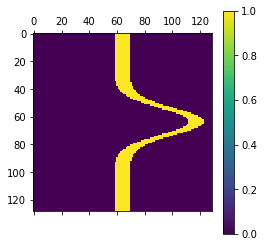

In [74]:
plt.matshow((np.abs(psi_0) < 1e-3))
plt.colorbar()
plt.show()

In [75]:
psi_0_vec = psi_0.flatten(order="F")

In [76]:
psi_0_vec.shape

(16641,)

In [77]:
psi_0_vec.shape

(16641,)

In [78]:
from scipy.sparse import lil_matrix

In [79]:
x_vals = np.linspace(L, R, N)
p_vals = np.linspace(L, R, N)
H = lil_matrix((N * N, N * N), dtype=np.complex64)
for i in range(N):

    p_val = p_vals[i]
    for j in range(N):
        x_val = x_vals[i]

        index = N * i + j

        # p derivative
        if i+1 < N:
            index_x_p = N * (i+1) + j
            H[index, index_x_p] = -0.5j * (-x_val) / h
            H[index_x_p, index] = 0.5j * (-x_val) / h
        if i-1 >= 0:
            index_x_m = N * (i-1) + j
            H[index, index_x_m] = 0.5j * (-x_val) / h
            H[index_x_m, index] = -0.5j * (-x_val) / h
        
        # x derivative
        if j+1 < N:
            index_p_p = N * i + j + 1
            H[index, index_p_p] = -0.5j * (p_val) / h
            H[index_p_p, index] = 0.5j * (p_val) / h
        if j-1 >= 0:
            index_p_m = N * i + j - 1
            H[index, index_p_m] = 0.5j * (p_val) / h
            H[index_p_m, index] = -0.5j * (p_val) / h

In [80]:
# F0_operator = diags([-0.5j * np.ones(N-1), 0.5j * np.ones(N-1)], offsets=[1 ,-1]) / h
# F1_operator = diags([-0.5j * np.ones(N-1), 0.5j * np.ones(N-1)], offsets=[1 ,-1]) / h

# H = kron(np.eye(N), F0_operator) #+ kron(F1_operator, np.eye(N))

In [81]:
psi = expm_multiply(-1j * H, psi_0_vec, 0, T, N_t)

In [82]:
for i in range(N_t):
    dist = np.reshape(np.abs(psi[i]) ** 2, (N,N), order="F")

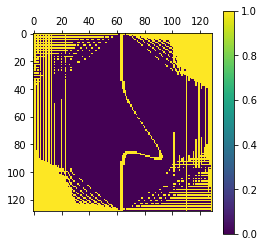

In [83]:
psi_reshaped = np.reshape(psi[20], (N,N), order="F")
im = plt.matshow((np.abs(psi_reshaped) < 5e-4))
plt.colorbar(im)
plt.show()

In [84]:
import matplotlib as mpl
import matplotlib.animation as animation

In [85]:
filename = "hj_original.gif"

.................

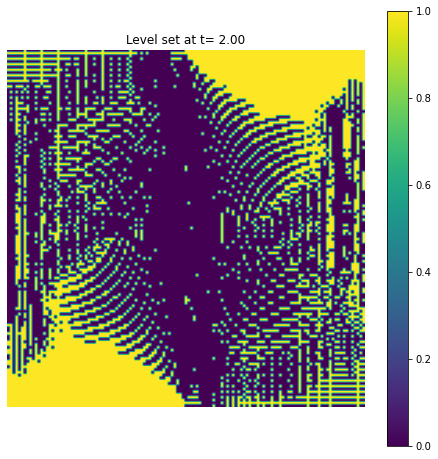

In [87]:
fps = 4
snapshots = [np.abs(np.reshape(psi[i], (N,N), order="F")) < 5e-4 for i in range(N_t)]
# First set up the figure, the axis, and the plot element we want to animate
fig = plt.figure(figsize=(8,8))

norm = mpl.colors.Normalize(vmin=0, vmax=np.max(snapshots[0]))
a = snapshots[0]
im = plt.imshow(a)
plt.title(f"Level set at t={times[0] : 0.2f}")
cb = plt.colorbar(im)
plt.axis("off")

def animate(i):
    if i % fps == 0:
        print( '.', end ='' )

    # plt.imshow(snapshots[i])
    im.set_data(snapshots[i])
    norm = mpl.colors.Normalize(vmin=0, vmax=np.max(snapshots[i]))
    im.set_norm(norm)
    plt.title(f"Level set at t={times[i] : 0.2f}")
    return [im]

anim = animation.FuncAnimation(fig, 
                               animate, 
                               frames=len(snapshots),
                               interval = 1000 # in ms
                               )
writergif = animation.PillowWriter(fps=fps)
anim.save(filename, writer=writergif)